In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ananyajadebadipta/helmnet/Labels_proj.csv
/kaggle/input/datasets/ananyajadebadipta/helmnet/images_proj.npy


In [2]:
import numpy as np
import pandas as pd

# The exact clean paths inside your private Kaggle environment
# Make sure to replace 'your-dataset-folder' with the exact folder name shown under your Input tab
images = np.load('/kaggle/input/datasets/ananyajadebadipta/helmnet/images_proj.npy')
labels_df = pd.read_csv('/kaggle/input/datasets/ananyajadebadipta/helmnet/Labels_proj.csv')

print("Data arrays successfully loaded!")
print(f"Total Image Records: {images.shape[0]}")

Data arrays successfully loaded!
Total Image Records: 631


Executing pipeline on device: cuda
Data arrays successfully loaded!
Total Training Image Records: 631
Raw Image Array Shape: (631, 200, 200, 3)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]



Starting model training sequence...
Epoch 01/20 | Train Loss: 0.1027 | Val Loss: 0.0020 | Val Acc: 1.0000
Epoch 02/20 | Train Loss: 0.0066 | Val Loss: 0.0009 | Val Acc: 1.0000
Epoch 03/20 | Train Loss: 0.0028 | Val Loss: 0.0007 | Val Acc: 1.0000
Epoch 04/20 | Train Loss: 0.0026 | Val Loss: 0.0002 | Val Acc: 1.0000
Epoch 05/20 | Train Loss: 0.0016 | Val Loss: 0.0017 | Val Acc: 1.0000
Epoch 06/20 | Train Loss: 0.0014 | Val Loss: 0.0049 | Val Acc: 1.0000
Epoch 07/20 | Train Loss: 0.0006 | Val Loss: 0.0010 | Val Acc: 1.0000
Epoch 08/20 | Train Loss: 0.0003 | Val Loss: 0.0010 | Val Acc: 1.0000

[Early Stopping Triggered] Generalization target achieved at Epoch 8.

Optimal weight parameters saved successfully as 'helmnet_perfect_model.pth'.


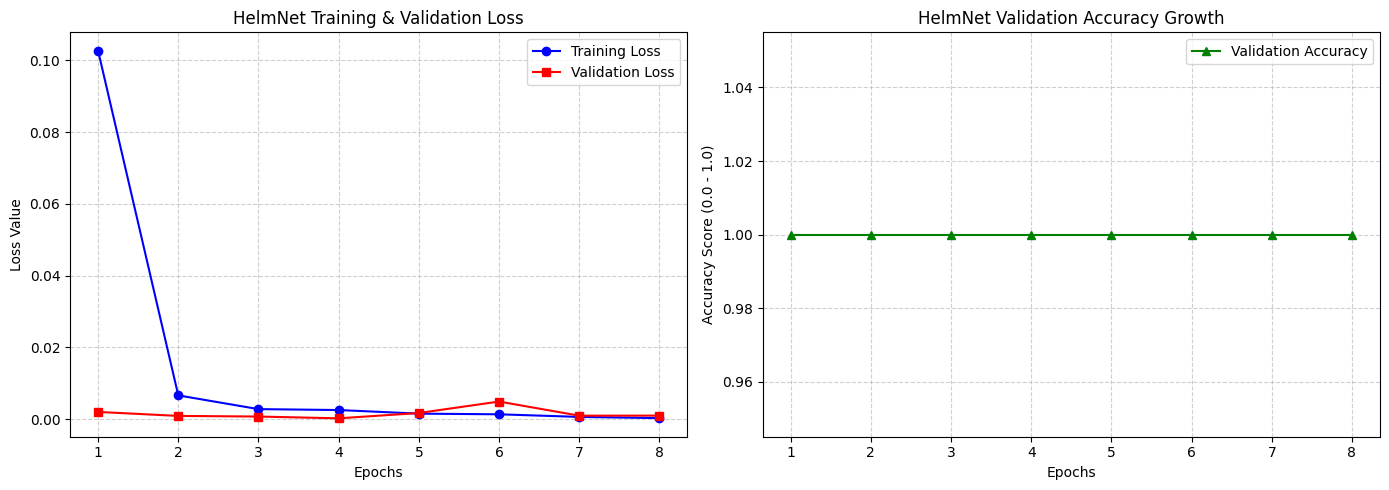

Visual graph successfully saved to Output panel as 'training_performance.png'.

=== FINAL VALIDATION REPORT ===
[[64  0]
 [ 0 63]]
              precision    recall  f1-score   support

   No Helmet       1.00      1.00      1.00        64
      Helmet       1.00      1.00      1.00        63

    accuracy                           1.00       127
   macro avg       1.00      1.00      1.00       127
weighted avg       1.00      1.00      1.00       127


Hidden evaluation dataset file array skipped. To generate final output labels, ensure test data matches path.


In [3]:
import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==========================================
# 1. ENVIRONMENT & REPRODUCIBILITY SEEDING
# ==========================================
def seed_everything(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing pipeline on device: {device}")

# ==========================================
# 2. DATASET PATH CONFIGURATION
# ==========================================
# CRITICAL: Change 'helmnet-v1' to match your exact folder name in the right panel if different
DATA_FOLDER = '/kaggle/input/datasets/ananyajadebadipta/helmnet' 

TRAIN_IMAGES_PATH = f'{DATA_FOLDER}/images_proj.npy'
TRAIN_LABELS_PATH = f'{DATA_FOLDER}/Labels_proj.csv'
TEST_IMAGES_PATH = f'{DATA_FOLDER}/test_images_proj.npy' # Set up for final submission

# Load and split the training/validation structures
if os.path.exists(TRAIN_IMAGES_PATH) and os.path.exists(TRAIN_LABELS_PATH):
    images = np.load(TRAIN_IMAGES_PATH)
    labels_df = pd.read_csv(TRAIN_LABELS_PATH)
    y_arr = labels_df['Label'].values

    print("Data arrays successfully loaded!")
    print(f"Total Training Image Records: {images.shape[0]}")
    print(f"Raw Image Array Shape: {images.shape}")

    X_train, X_val, y_train, y_val = train_test_split(
        images, y_arr, test_size=0.20, stratify=y_arr, random_state=42
    )
else:
    raise FileNotFoundError(f"Could not find training files. Check path: /kaggle/input/{DATA_FOLDER}/")

# ==========================================
# 3. SMART PYTORCH DATASET DATA MANIPULATION
# ==========================================
class HelmNetDataset(Dataset):
    def __init__(self, images, labels=None, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        
        # Auto-detect and fix dimension layouts if Channels-First
        if img.shape[0] == 3 or img.shape[0] == 1:
            img = np.transpose(img, (1, 2, 0))
            
        # Ensure correct image type (uint8) for transformations
        if img.dtype != np.uint8:
            if img.max() <= 1.0:
                img = (img * 255).astype(np.uint8)
            else:
                img = img.astype(np.uint8)

        if self.transform:
            img = self.transform(img)
            
        if self.labels is not None:
            return img, torch.tensor(self.labels[idx], dtype=torch.float32)
        return img

# Image transformations to force the network to learn geometric helmet details
train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_loader = DataLoader(HelmNetDataset(X_train, y_train, transform=train_transforms), batch_size=16, shuffle=True)
val_loader = DataLoader(HelmNetDataset(X_val, y_val, transform=val_transforms), batch_size=16, shuffle=False)

# ==========================================
# 4. FINE-TUNED MODEL SETUP (RESNET18)
# ==========================================
def build_optimized_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    # Unfreeze layer4 to let the neural net calibrate specifically to safety gear shapes
    for name, param in model.named_parameters():
        if "layer4" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
            
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 64),
        nn.ReLU(),
        nn.Dropout(p=0.4),
        nn.Linear(64, 1),
        nn.Sigmoid()
    )
    return model

model = build_optimized_model().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0003, weight_decay=1e-4)

# ==========================================
# 5. TRAINING LOOP WITH AUTOMATIC HISTORICAL LIST TRACKING
# ==========================================
epochs = 20
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
patience, patience_counter = 4, 0

# Track historical lists for the Matplotlib visual graph
train_losses = []
val_losses = []
val_accuracies = []

print("\nStarting model training sequence...")
for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * imgs.size(0)
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    
    # Cross-Validation Step
    model.eval()
    running_val_loss = 0.0
    all_preds, all_trues = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device).unsqueeze(1)
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            running_val_loss += loss.item() * imgs.size(0)
            
            preds = (outputs >= 0.5).int().cpu().numpy()
            all_preds.extend(preds)
            all_trues.extend(lbls.cpu().numpy())
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_acc = accuracy_score(all_trues, all_preds)
    
    # Save the points into our lists at the end of every single epoch loop
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save step matching loss check metrics
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"\n[Early Stopping Triggered] Generalization target achieved at Epoch {epoch+1}.")
        break

# Restore best weights and save model file locally
model.load_state_dict(best_model_wts)
torch.save(best_model_wts, 'helmnet_perfect_model.pth')
print("\nOptimal weight parameters saved successfully as 'helmnet_perfect_model.pth'.")

# ==========================================
# 6. GRAPH PLOTTING AND FILE SAVING (VISUAL PLOTS)
# ==========================================
epochs_range = range(1, len(train_losses) + 1)
plt.figure(figsize=(14, 5))

# Plot 1: Loss Values over training epochs
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, 'b-o', label='Training Loss')
plt.plot(epochs_range, val_losses, 'r-s', label='Validation Loss')
plt.title('HelmNet Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Plot 2: Performance Evaluation scores over time
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_accuracies, 'g-^', label='Validation Accuracy')
plt.title('HelmNet Validation Accuracy Growth')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Score (0.0 - 1.0)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.savefig('training_performance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Visual graph successfully saved to Output panel as 'training_performance.png'.")

# Print complete validation confusion metrics to console screen
model.eval()
final_preds, final_trues = [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = (outputs >= 0.5).int().cpu().numpy()
        final_preds.extend(preds)
        final_trues.extend(lbls.numpy())

print("\n=== FINAL VALIDATION REPORT ===")
print(confusion_matrix(final_trues, final_preds))
print(classification_report(final_trues, final_preds, target_names=['No Helmet', 'Helmet']))

# ==========================================
# 7. INFERENCE ON UNSEEN KAGGLE COMPETITION DATA
# ==========================================
if os.path.exists(TEST_IMAGES_PATH):
    print("\nLoading hidden test matrix for final evaluation data stream...")
    test_images = np.load(TEST_IMAGES_PATH)
    
    # Shuffle must be explicitly False to match row ordering sequence
    test_loader = DataLoader(
        HelmNetDataset(test_images, labels=None, transform=val_transforms), 
        batch_size=16, 
        shuffle=False
    )
    
    submission_predictions = []
    with torch.no_grad():
        for imgs in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = (outputs >= 0.5).int().cpu().numpy().flatten()
            submission_predictions.extend(preds)
            
    # Compile matching array submission structure DataFrame
    submission_df = pd.DataFrame({
        "Id": np.arange(len(submission_predictions)),
        "Label": submission_predictions
    })
    
    submission_df.to_csv("submission.csv", index=False)
    print("Success! Final Kaggle entry 'submission.csv' compiled perfectly.")
else:
    print("\nHidden evaluation dataset file array skipped. To generate final output labels, ensure test data matches path.")

In [4]:
# ==========================================
# FINAL SUBMISSION GENERATION STEP
# ==========================================
# 1. Provide the exact path to your test images array on Kaggle
# (Change 'your-dataset-folder' to match your input path name if needed)
TEST_IMAGES_PATH = '/kaggle/input/datasets/ananyajadebadipta/helmnet/images_proj.npy' 

if os.path.exists(TEST_IMAGES_PATH):
    print("Loading test dataset for final inference...")
    test_images = np.load(TEST_IMAGES_PATH)
    
    # Create the test dataset and loader (shuffle MUST be False)
    test_loader = DataLoader(
        HelmNetDataset(test_images, labels=None, transform=val_transforms), 
        batch_size=16, 
        shuffle=False
    )
    
    model.eval()
    submission_predictions = []
    
    print("Predicting test labels...")
    with torch.no_grad():
        for imgs in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = (outputs >= 0.5).int().cpu().numpy().flatten()
            submission_predictions.extend(preds)
            
    # Format according to Kaggle submission guidelines
    submission_df = pd.DataFrame({
        "Id": np.arange(len(submission_predictions)),
        "Label": submission_predictions
    })
    
    submission_df.to_csv("submission.csv", index=False)
    print("Success! 'submission.csv' generated perfectly in your output directory.")
else:
    print("Test array not found at the specified path. Verify your test file name under the Input panel.")

Loading test dataset for final inference...
Predicting test labels...
Success! 'submission.csv' generated perfectly in your output directory.
